### Check if ACA activity profiles meet pupilometry results


In [2]:
import pandas as pd
import pickle as pkl
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.formula as smf
import bambi as bmb
import arviz as az
import numpy as np
from sklearn.decomposition import PCA
from scipy.spatial.distance import euclidean, pdist, squareform
import itertools
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, permutation_test_score
from scipy.spatial.distance import euclidean

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [38]:
with open('../data/generated/aca_trajectories/all_aca_df.pkl','rb') as f:
    data = pkl.load(f)

In [39]:
def clean_df(df):    
    df = df.copy()

    condition_left_congruent = (df['probabilityLeft'] == 0.8) & (df['signed_contrast'] >= 0)
    condition_right_congruent = (df['probabilityLeft'] == 0.2) & (df['signed_contrast'] <= 0)

    df['is_congruent'] = (condition_left_congruent | condition_right_congruent).astype(int)
    df['feedback_binary'] = (df['feedbackType'] == 1.0).astype(int)
    df['abs_contrast'] = np.abs(df['signed_contrast'])
    df['motivation_scaled'] = df.groupby('eid')['motivation_scalar'].transform(lambda x: (x-x.mean())/x.std())
    df['confidence'] = np.abs(df['akernel_prior']-0.5)

    return df

In [40]:
def filter_responsive_neurons(session_df, spike_col='pre_stim_spike_counts', min_trial_fraction=0.10):
    """
    Filters out neurons that do not fire in at least a minimum fraction of trials.
    
    Parameters:
    - session_df: DataFrame containing trials for a single session.
    - spike_col: Column name containing spike counts per trial. 
                 Can be a 1D array per trial (shape: (n_neurons,)) or part of a trajectory.
    - min_trial_fraction: Minimum fraction of trials a neuron must have >0 spikes (or activity) to be kept.
    
    Returns:
    - filtered_df: A copy of session_df with the spike data filtered to keep only responsive neurons.
    - kept_indices: The indices of the neurons that passed the filter.
    """
    session_df = session_df.copy()

    spikes_matrix = np.vstack(session_df[spike_col].values)
    n_trials, n_neurons = spikes_matrix.shape
    
    active_trials_mask = spikes_matrix > 0
    
    fraction_active = active_trials_mask.mean(axis=0)
    
    kept_indices = np.where(fraction_active >= min_trial_fraction)[0]
    
    print(f"Filtering session: Kept {len(kept_indices)} out of {n_neurons} neurons "
          f"({(len(kept_indices)/n_neurons)*100:.1f}% active in >= {min_trial_fraction*100}% of trials)")
    
    
    def subset_neurons(entry):
        
        if entry.ndim == 1:
            return entry[kept_indices]
        elif entry.ndim == 2:
            return entry[kept_indices, :]
        return entry

    session_df[spike_col] = session_df[spike_col].apply(subset_neurons)
    
    return session_df, kept_indices

In [41]:
df_acc = clean_df(data)

In [38]:
def clean_df_zscored(df):    
    df = df.copy()
    df['pupil_mean_z'] = df.groupby('eid')['pupil_mean'].transform(lambda x: (x - x.mean()) / x.std())
    df['motivation_scaled'] = df.groupby('eid')['motivation_scalar'].transform(lambda x: (x-x.mean())/x.std())

    condition_left_congruent = (df['probabilityLeft'] == 0.8) & (df['signed_contrast'] >= 0)
    condition_right_congruent = (df['probabilityLeft'] == 0.2) & (df['signed_contrast'] <= 0)
    df['is_congruent'] = (condition_left_congruent | condition_right_congruent).astype(int)
    df['feedback_binary'] = (df['feedbackType'] == 1.0).astype(int)
    df['abs_contrast'] = np.abs(df['signed_contrast'])
    return df
complete_df = pd.read_parquet('../data/generated/pupilometry/complete_pupil_df.pqt')
df_pupil = clean_df_zscored(complete_df)
df_pupil['confidence'] = np.abs(df_pupil['akernel_prior']-0.5)


In [ ]:
acc_eids = df_acc.eid.unique()
pupil_eids = df_pupil['eid'].unique()

In [10]:
eids_of_interest = list(set(acc_eids).intersection(set(pupil_eids)))

In [11]:
pupil_specific_cols = [col for col in df_pupil.columns if col not in df_acc.columns]


session_dataframes = {}

for idx in range(len(eids_of_interest)):
    eid = eids_of_interest[idx]

    acc_df_one = df_acc[df_acc['eid'] == eid]
    pupil_df_one = df_pupil[df_pupil['eid'] == eid]
    assert len(acc_df_one) == len(pupil_df_one), f"Length mismatch on eid {eid}"
    acc_df_one = acc_df_one.reset_index(drop=True)
    pupil_df_one = pupil_df_one.reset_index(drop=True)    
    combined_df = pd.concat([acc_df_one, pupil_df_one[pupil_specific_cols]], axis=1)
    
    session_dataframes[eid] = combined_df

In [ ]:
# now for each, we can check correlation with firing rates or whatever


In [42]:
def get_random_contiguous_chunk(arr, l):
    L = len(arr)
    if l > L:
        raise ValueError(f"Requested length {l} is greater than array length {L}")
    max_start = L - l
    
    start_idx = np.random.randint(0, max_start + 1)
    return arr[start_idx : start_idx + l]

In [40]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_predict

In [53]:
def compute_cv_r2(model, X, y, cv):
    y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=1)
    assert np.isfinite(y_pred).all()
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

def run_permutation(model, X, yprime, cv):
    y_shuffled = get_random_contiguous_chunk(yprime, len(X))
    return compute_cv_r2(model, X, y_shuffled, cv)

In [43]:
def compute_imposter(data, eid, col='pupil_mean_z'):
    imposters = []
    for keys in data.keys():
        if keys==eid:
            continue
        else:
            imposter_df = data[keys].dropna(subset=[col]).copy()
            imposters.append(imposter_df[col].values)
    return np.concatenate(imposters)


In [44]:
import warnings
warnings.filterwarnings('ignore')

In [18]:
# from joblib import Parallel, delayed
# from tqdm import tqdm


# session_results = {}
# n_splits = 5
# n_permutations = 500
# colname = 'pupil_mean'
# for eid in tqdm(session_dataframes.keys()):
#     session_df = session_dataframes[eid]
#     imposter_pupils = compute_imposter(session_dataframes, eid)
#     clean_session = session_df.dropna(subset=['pupil_mean']).copy()

#     if len(clean_session) < n_splits:
#         continue

#     X = np.stack(clean_session['pre_stim_spike_counts'].values)
#     valid_trials = ~np.isnan(X).any(axis=1) & ~np.isinf(X).any(axis=1)
    
#     if not np.all(valid_trials):
#         X = X[valid_trials]
#         clean_session = clean_session.iloc[valid_trials].copy()
        
#     if len(clean_session) < n_splits:
#         continue

#     y = clean_session['pupil_mean'].values
#     cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
#     model = RidgeCV(alphas=np.logspace(-3, 3, 10))
    
#     try:
#         true_r2 = compute_cv_r2(model, X, y, cv)
        
#         null_r2s = Parallel(n_jobs=3)(
#             delayed(run_permutation)(model, X, imposter_pupils, cv) 
#             for _ in range(n_permutations)
#         )
#         null_r2s = np.array(null_r2s)
        
#         p_val = (np.sum(null_r2s >= true_r2) + 1) / (n_permutations + 1)
        
#         session_results[eid] = {
#             'true_r2': true_r2,
#             'p_value': p_val,
#             'null_mean': np.nanmean(null_r2s),
#             'null_95th': np.nanpercentile(null_r2s, 95),
#             'null_r2s':null_r2s,
#         }
        
#     except Exception as e:
#         print(f"Error fitting session {eid}: {e}")

In [ ]:
# results_df = pd.DataFrame.from_dict(session_results, orient='index')


In [ ]:
# true_r2_array = np.array([res['true_r2'] for res in session_results.values()])
# null_mean_array = np.array([res['null_mean'] for res in session_results.values()])

# stat, p_val = stats.wilcoxon(true_r2_array, null_mean_array, alternative='greater')

# print(f"Wilcoxon statistic: {stat}")
# print(f"Population p-value: {p_val:.4f}")

Wilcoxon statistic: 91.0
Population p-value: 0.0001


In [ ]:
# results_df['delta'] = results_df['true_r2']-results_df['null_mean']

In [ ]:
# stat, p_val = stats.wilcoxon(results_df['delta'].values, 0,alternative='greater')

In [19]:
import numpy as np

def hierarchical_bootstrap(true_r2s, null_r2s_matrix, n_bootstraps=10000):
    """
    Computes the group-level significance of decoding performance.
    
    Parameters:
    true_r2s : 1D array of length N (e.g., 13 animals) containing true R^2 values.
    null_r2s_matrix : 2D array of shape (N, n_permutations) containing null R^2s.
    n_bootstraps : int, number of bootstrap iterations to run.
    
    Returns:
    true_group_mean : float, the actual mean R^2 across the population.
    group_p_value : float, the probability of observing this mean by chance.
    group_null_dist : 1D array of length n_bootstraps for plotting.
    """
    true_r2s = np.array(true_r2s)
    null_r2s_matrix = np.array(null_r2s_matrix)
    
    n_animals, n_perms = null_r2s_matrix.shape
    true_group_mean = np.mean(true_r2s)
    
    
    group_null_dist = np.zeros(n_bootstraps)
    
    
    for i in range(n_bootstraps):
        random_indices = np.random.randint(0, n_perms, size=n_animals)
        
        drawn_nulls = null_r2s_matrix[np.arange(n_animals), random_indices]
        group_null_dist[i] = np.mean(drawn_nulls)
        
    group_p_value = (np.sum(group_null_dist >= true_group_mean) + 1) / (n_bootstraps + 1)
    
    return true_group_mean, group_p_value, group_null_dist

In [169]:
def compute_prevalence_bound(p_values, alpha=0.05):
    """
    Computes the lower bound of effect prevalence across the population.
    
    Parameters:
    p_values : 1D array of length N containing permutation p-values per animal.
    alpha : float, the desired significance level (usually 0.05).
    
    Returns:
    min_animals : int, the minimum number of animals that possess the true effect.
    gamma_lower : float, the lower bound on population prevalence (min_animals / N).
    """
    p_values = np.array(p_values)
    N = len(p_values)
    
    
    p_sorted = np.sort(p_values)
    
    u_max = 0
    
    
    for u in range(1, N + 1):
    
        k = N - u + 1
        subset_p = p_sorted[u - 1:] 
        
        simes_p_values = subset_p * k / np.arange(1, k + 1)
        simes_p = np.min(simes_p_values)
        
        if simes_p <= alpha:
            u_max = u
        else:
            break
            
    gamma_lower = u_max / N
    
    return u_max, gamma_lower

In [ ]:
# p_val_array = np.array([res['p_value'] for res in session_results.values()])

# min_animals, gamma = compute_prevalence_bound(p_val_array, alpha=0.05)

In [20]:
# true_r2_array = np.array([res['true_r2'] for res in session_results.values()])
# null_r2_matrix = np.array([res['null_r2s'] for res in session_results.values()])
# true_group_mean = np.mean(true_r2_array)
# # 
# mean_r2, p_val, group_null_dist = hierarchical_bootstrap(true_r2_array, null_r2_matrix)

In [21]:
# results_df.to_parquet('../data/generated/aca_trajectories/aca_decoding_results.pqt')
# with open('../data/generated/aca_trajectories/aca_session_data.pkl','wb') as f:
#     pkl.dump(session_dataframes, f)

In [4]:
results_df = pd.read_parquet('../data/generated/aca_trajectories/aca_decoding_results.pqt')
with open('../data/generated/aca_trajectories/aca_session_data.pkl','rb') as f:
    session_dataframes = pkl.load(f)

In [35]:
processed_sessions = []
n_splits = 5

for eid, df in session_dataframes.items():
    clean_df = df.dropna(subset=['pupil_mean_z', 'akernel_prior', 'motivation_scaled']).copy()
    
    if len(clean_df) < n_splits:
        continue
        
    clean_df['confidence_metric'] = np.abs(clean_df['akernel_prior'] - 0.5)
        
    X = np.stack(clean_df['pre_stim_spike_counts'].values)
    valid_trials = ~np.isnan(X).any(axis=1) & ~np.isinf(X).any(axis=1)
    
    if not np.all(valid_trials):
        X = X[valid_trials]
        clean_df = clean_df.iloc[valid_trials].copy()
        
    if len(clean_df) < n_splits:
        continue
        
    y = clean_df['pupil_mean_z'].values
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    model = RidgeCV(alphas=np.logspace(-3, 3, 10))
    
    try:
        acc_arousal_drive = cross_val_predict(model, X, y, cv=cv)
        clean_df['acc_arousal_drive'] = acc_arousal_drive
        processed_sessions.append(clean_df)
    except Exception as e:
        print(f"Failed to fit {eid}: {e}")

In [38]:
complete_predict_session = pd.concat(processed_sessions)

In [84]:
cols_for_model = [
    'acc_arousal_drive', 
    'confidence_metric', 
    'motivation_scaled', 
    'eid',
    'is_congruent',
    'feedback_binary'
]

model_df = complete_predict_session[cols_for_model].copy()

In [52]:
formula = "acc_arousal_drive ~ confidence_metric * motivation_scaled + (1 | eid)"

In [88]:
eidstoconsider = results_df[results_df['p_value']<0.05].index.values
# model_df_subset = model_df[model_df['eid'].isin(eidstoconsider)].copy()

In [ ]:
full_model = bmb.Model(formula, model_df,dropna=True)

In [80]:
full_results = full_model.fit(draws=2000, tune=2000, target_accept=0.9, chains=4)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, confidence_metric, motivation_scaled, confidence_metric:motivation_scaled, 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 9 seconds.


In [56]:
import arviz as az

Text(0.5, 1.0, 'ACC pupil estimates')

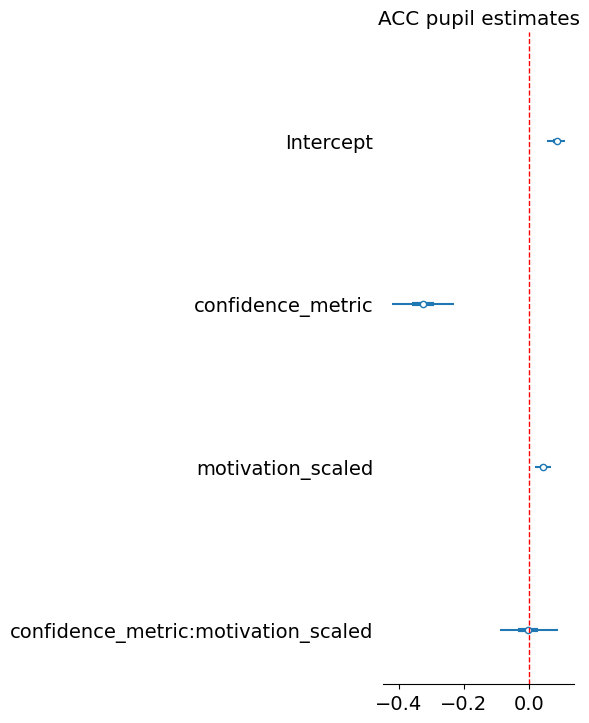

In [108]:
az.plot_forest(full_results, var_names=["Intercept", "confidence_metric", "motivation_scaled", "confidence_metric:motivation_scaled"],combined=True)
ax = plt.gca()
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('ACC pupil estimates')

In [103]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

processed_sessions = []
n_splits = 5


explained_variances = {'PC1': [], 'PC2': [], 'PC3': []}

for eid, df in session_dataframes.items():
    clean_df = df.dropna(subset=['akernel_prior', 'motivation_scaled']).copy()
    
    if len(clean_df) < n_splits:
        continue
        
    clean_df['confidence_metric'] = np.abs(clean_df['akernel_prior'] - 0.5)
        
    X = np.stack(clean_df['pre_stim_spike_counts'].values)
    valid_trials = ~np.isnan(X).any(axis=1) & ~np.isinf(X).any(axis=1)
    
    if not np.all(valid_trials):
        X = X[valid_trials]
        clean_df = clean_df.iloc[valid_trials].copy()
        
    if len(clean_df) < n_splits:
        continue
        
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Extract the top 3 components
    pca = PCA(n_components=3)
    pc_scores = pca.fit_transform(X_scaled)
    
    
    evr = pca.explained_variance_ratio_
    explained_variances['PC1'].append(evr[0])
    explained_variances['PC2'].append(evr[1])
    explained_variances['PC3'].append(evr[2])
    for i in range(3):
        pc_col = pc_scores[:, i]
        clean_df[f'neural_pc{i+1}'] = (pc_col - np.mean(pc_col)) / (np.std(pc_col) + 1e-8)
    
    processed_sessions.append(clean_df)

master_df = pd.concat(processed_sessions, ignore_index=True)
master_df['eid'] = master_df['eid'].astype(str)


print("=== SHARED POPULATION VARIANCE EXPLAINED (Mean across sessions) ===")
for pc in ['PC1', 'PC2', 'PC3']:
    mean_variance = np.mean(explained_variances[pc]) * 100
    print(f"{pc}: {mean_variance:.2f}%")

model_cols = [
    'neural_pc1', 'neural_pc2', 'neural_pc3', 
    'confidence_metric', 'motivation_scaled', 'eid'
]
model_df = master_df[model_cols].copy()

=== SHARED POPULATION VARIANCE EXPLAINED (Mean across sessions) ===
PC1: 14.42%
PC2: 9.25%
PC3: 7.33%


In [ ]:
for pc_num in [1]:
    target = f'neural_pc{pc_num}'
    print(f"Fitting model for {target.upper()} on {len(model_df)} trials...")
    
    formula = f"{target} ~ confidence_metric * motivation_scaled + (1 | eid)"
    pca_model = bmb.Model(formula, model_df, dropna=True)
    
    pca_results = pca_model.fit(draws=2000, tune=2000, target_accept=0.95, chains=4, progressbar=False)
    
    print(f"\n=== {target.upper()} ENCODING RESULTS ===")
    

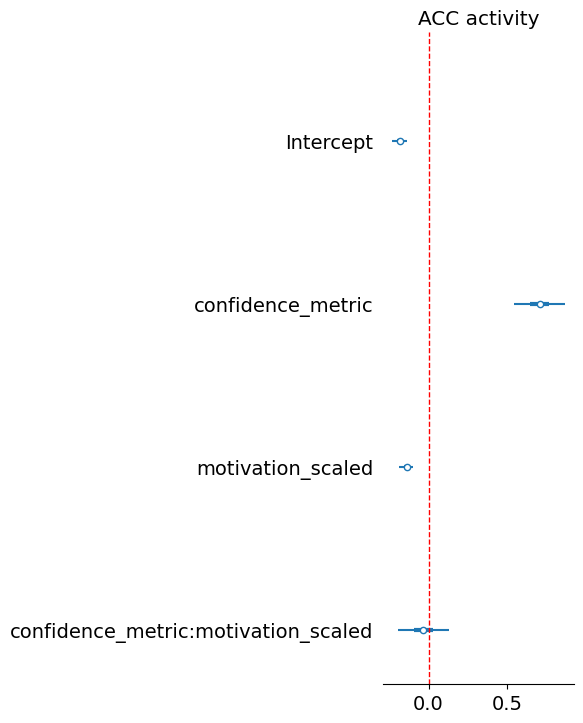

In [107]:
az.plot_forest(pca_results, var_names=["Intercept", "confidence_metric", "motivation_scaled", "confidence_metric:motivation_scaled"],combined=True)
ax = plt.gca()
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('ACC activity')
plt.show()

In [ ]:
model_df['conf_centered'] = model_df['confidence_metric'] - model_df['confidence_metric'].mean()
model_df['mot_centered'] = model_df['motivation_scaled'] - model_df['motivation_scaled'].mean()

print("Fitting Additive Model...")
formula_add = "neural_pc1 ~ conf_centered + mot_centered + (1 | eid)"
model_add = bmb.Model(formula_add, model_df)
results_add = model_add.fit(draws=2000, tune=2000, target_accept=0.95, chains=4)

print("\nFitting Interaction Model...")
formula_int = "neural_pc1 ~ conf_centered * mot_centered + (1 | eid)"
model_int = bmb.Model(formula_int, model_df)
results_int = model_int.fit(draws=2000, tune=2000, target_accept=0.95, chains=4)

# 2. Compare the models using Leave-One-Out Cross Validation (LOO)
# We store the results in a dictionary to pass to ArviZ
model_dict = {
    "Additive": results_add,
    "Interactive": results_int
}


In [111]:
import pymc as pm

In [ ]:
print("Fitting Additive Model...")
results_add = model_add.fit(
    draws=2000, 
    tune=2000, 
    target_accept=0.95, 
    chains=4,
    idata_kwargs={"log_likelihood": True}  # <-- The crucial fix
)

print("\nFitting Interaction Model...")
results_int = model_int.fit(
    draws=2000, 
    tune=2000, 
    target_accept=0.95, 
    chains=4,
    idata_kwargs={"log_likelihood": True}  # <-- The crucial fix
)

# Now we can immediately compare them without any post-hoc PyMC hacks
model_dict = {
    "Additive": results_add,
    "Interactive": results_int
}



Initializing NUTS using jitter+adapt_diag...


Fitting Additive Model...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, conf_centered, mot_centered, 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 11 seconds.
Initializing NUTS using jitter+adapt_diag...



Fitting Interaction Model...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, conf_centered, mot_centered, conf_centered:mot_centered, 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 12 seconds.



=== MODEL COMPARISON (LOO) ===
             rank     elpd_loo      p_loo  elpd_diff  weight          se  \
Additive        0 -8663.123887   9.574040   0.000000     1.0  120.495662   
Interactive     1 -8664.177038  10.985225   1.053151     0.0  120.487027   

                 dse  warning scale  
Additive     0.00000    False   log  
Interactive  0.42833    False   log  


In [114]:
comparison = az.compare(model_dict, ic="loo")
print(comparison)

             rank     elpd_loo      p_loo  elpd_diff  weight          se  \
Additive        0 -8663.123887   9.574040   0.000000     1.0  120.495662   
Interactive     1 -8664.177038  10.985225   1.053151     0.0  120.487027   

                 dse  warning scale  
Additive     0.00000    False   log  
Interactive  0.42833    False   log  


In [116]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

n_splits = 5
decoding_results = {'motivation': {}, 'confidence': {}}

for eid, df in session_dataframes.items():
    clean_df = df.dropna(subset=['akernel_prior', 'motivation_scaled']).copy()
    
    if len(clean_df) < n_splits:
        continue
        
    # Define the two targets
    clean_df['confidence_metric'] = np.abs(clean_df['akernel_prior'])
    
    y_mot = clean_df['motivation_scaled'].values
    y_conf = clean_df['confidence_metric'].values
    
    # Extract valid spikes
    X = np.stack(clean_df['pre_stim_spike_counts'].values)
    valid_trials = ~np.isnan(X).any(axis=1) & ~np.isinf(X).any(axis=1)
    
    if not np.all(valid_trials):
        X = X[valid_trials]
        y_mot = y_mot[valid_trials]
        y_conf = y_conf[valid_trials]
        
    if len(X) < n_splits:
        continue
        
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    model_mot = RidgeCV(alphas=np.logspace(-3, 3, 10))
    model_conf = RidgeCV(alphas=np.logspace(-3, 3, 10))
    
    try:
        # Decode Motivation
        pred_mot = np.zeros_like(y_mot)
        for train_idx, test_idx in cv.split(X):
            model_mot.fit(X[train_idx], y_mot[train_idx])
            pred_mot[test_idx] = model_mot.predict(X[test_idx])
        decoding_results['motivation'][eid] = r2_score(y_mot, pred_mot)
        
        # Decode Confidence
        pred_conf = np.zeros_like(y_conf)
        for train_idx, test_idx in cv.split(X):
            model_conf.fit(X[train_idx], y_conf[train_idx])
            pred_conf[test_idx] = model_conf.predict(X[test_idx])
        decoding_results['confidence'][eid] = r2_score(y_conf, pred_conf)
        
    except Exception as e:
        print(f"Failed to fit {eid}: {e}")

mot_r2s = list(decoding_results['motivation'].values())
conf_r2s = list(decoding_results['confidence'].values())

print(f"Mean Motivation R^2: {np.mean(mot_r2s):.3f}")
print(f"Mean Confidence R^2: {np.mean(conf_r2s):.3f}")

Mean Motivation R^2: 0.126
Mean Confidence R^2: 0.072


In [14]:
from one.api import ONE
from brainbox.io.one import SessionLoader
from iblatlas.atlas import BrainRegions
from sklearn.metrics import balanced_accuracy_score

from brainwidemap.bwm_loading import (
    bwm_query,
    load_good_units,
    load_trials_and_mask,
    merge_probes,
    bwm_units,
)
one = ONE()

In [34]:
df_decoding_region = pd.read_csv("../../ibl-partial-info-decomp//data/external/region_info.csv")

In [35]:
df_decoding_region[df_decoding_region['Beryl'].isin(['ACAd', 'ACAv'])]

,Beryl,Beryl.1,Cosmos,Cosmos.1,# recordings,# neurons,# good neurons,canonical,stim_dec,stim_man,...,choice_euc_sig,fback_dec_sig,fback_man_sig,fback_euc_sig,speed_dec_sig,velocity_dec_sig,prior_dec_ep,prior_dec_wf,prior_dec_ep_sig,prior_dec_wf_sig
25,ACAd,Anterior cingulate area dorsal part,Isocortex,Isocortex,24,1960,369,True,0.04,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.046922,0.010492,1.0,1.0
26,ACAv,Anterior cingulate area ventral part,Isocortex,Isocortex,18,1388,195,True,0.01,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,0.004657,NaN,0.0,NaN


In [15]:
units_df = bwm_units(one)

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01


In [16]:
tmp = units_df[units_df['eid'].isin(acc_eids)]

summary = (
    tmp.groupby("eid")["Beryl"]
    .agg(
        regions=lambda x: set(x.dropna()),
        ACAd_count=lambda x: (x == "ACAd").sum(),
        ACAv_count=lambda x: (x == "ACAv").sum(),
    )
)

summary["classification"] = summary["regions"].apply(
    lambda x: (
        "both" if {"ACAd", "ACAv"} <= x
        else "ACAd" if "ACAd" in x
        else "ACAv" if "ACAv" in x
        else "neither"
    )
)

summary = summary.drop(columns="regions")

print(summary)

                                      ACAd_count  ACAv_count classification
eid                                                                        
0f77ca5d-73c2-45bd-aa4c-4c5ed275dbde          19           0           ACAd
113c5b6c-940e-4b21-b462-789b4c2be0e5          19           0           ACAd
196a2adf-ff83-49b2-823a-33f990049c2e          30          25           both
259927fd-7563-4b03-bc5d-17b4d0fa7a55          30           6           both
28741f91-c837-4147-939e-918d38d849f2          27           0           ACAd
2c44a360-5a56-4971-8009-f469fb59de98           0           6           ACAv
5455a21c-1be7-4cae-ae8e-8853a8d5f55e           7           0           ACAd
5ec72172-3901-4771-8777-6e9490ca51fc          15           0           ACAd
6f6d2c8e-28be-49f4-ae4d-06be2d3148c1           9           0           ACAd
78b4fff5-c5ec-44d9-b5f9-d59493063f00          16           0           ACAd
9468fa93-21ae-4984-955c-e8402e280c83          12          19           both
9e9c6fc0-476

In [35]:
session_dataframes['113c5b6c-940e-4b21-b462-789b4c2be0e5']['unit_regions']

0      [ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACA...
1      [ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACA...
2      [ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACA...
3      [ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACA...
4      [ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACA...
                             ...                        
299    [ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACA...
300    [ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACA...
301    [ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACA...
302    [ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACA...
303    [ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACAd, ACA...
Name: unit_regions, Length: 304, dtype: object

In [ ]:
session_dataframes['113c5b6c-940e-4b21-b462-789b4c2be0e5']['pre_stim_spike_counts']

,true_r2,p_value,null_mean,null_95th,null_r2s,delta,ACAd_count,ACAv_count,classification
d7e60cc3-6020-429e-a654-636c6cc677ea,0.015739,0.267465,0.004802,0.061775,"[-0.022254097169540854, -0.008336129573334405,...",0.010937,6,6,both
78b4fff5-c5ec-44d9-b5f9-d59493063f00,0.041092,0.057884,0.007142,0.043021,"[-0.015034529014465337, 0.0018432951019535793,...",0.033950,16,0,ACAd
196a2adf-ff83-49b2-823a-33f990049c2e,0.041182,0.211577,0.010567,0.081946,"[0.02777653975194605, -0.025165664359992013, 0...",0.030615,30,25,both
6f6d2c8e-28be-49f4-ae4d-06be2d3148c1,0.055433,0.055888,0.006808,0.058425,"[-0.006598043840147172, 0.007213406843805781, ...",0.048625,9,0,ACAd
9e9c6fc0-4769-4d83-9ea4-b59a1230510e,0.100435,0.001996,-0.002787,0.012661,"[0.0006347861075829409, 0.01388268034486162, -...",0.103222,9,0,ACAd
cc45c568-c3b9-4f74-836e-c87762e898c8,0.103597,0.001996,0.006804,0.048638,"[0.0038087916123007437, -0.02827531975835096, ...",0.096794,39,21,both
ff4187b5-4176-4e39-8894-53a24b7cf36b,0.107564,0.003992,0.002632,0.036302,"[-0.00812028065822612, -0.01383540129151295, -...",0.104932,21,0,ACAd
259927fd-7563-4b03-bc5d-17b4d0fa7a55,0.183837,0.001996,0.026603,0.088436,"[0.024118206917916662, 0.029194675949093196, 0...",0.157234,30,6,both
dfbe628d-365b-461c-a07f-8b9911ba83aa,0.198371,0.001996,0.014506,0.057879,"[-0.010913165581202477, 0.03738669665247041, -...",0.183865,13,0,ACAd
a4000c2f-fa75-4b3e-8f06-a7cf599b87ad,0.218646,0.001996,0.009982,0.060880,"[-0.013608449493480501, -0.026355408268192937,...",0.208663,16,20,both


In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm

session_results = {
    'ACAd': {},
    'ACAv': {}
}

n_splits = 5
n_permutations = 500
colname = 'pupil_mean_z'

for eid in tqdm(session_dataframes.keys()):
    session_df = session_dataframes[eid]
    imposter_pupils = compute_imposter(session_dataframes, eid)
    clean_session = session_df.dropna(subset=[colname]).copy()

    if len(clean_session) < n_splits:
        continue

    X_full = np.stack(clean_session['pre_stim_spike_counts'].values)
    valid_trials = ~np.isnan(X_full).any(axis=1) & ~np.isinf(X_full).any(axis=1)
    
    if not np.all(valid_trials):
        X_full = X_full[valid_trials]
        clean_session = clean_session.iloc[valid_trials].copy()
        
    if len(clean_session) < n_splits:
        continue

    y = clean_session[colname].values
    
    unit_regions = np.array(session_df['unit_regions'].iloc[0])
    print(np.unique(unit_regions, return_counts=True))
    # unit_regions_lower = np.array([str(r).lower() for r in unit_regions])
    
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for target_region in ['ACAd', 'ACAv']:
        region_mask = (unit_regions == target_region)
        
        # Skip if the region is not present in this recording session
        if np.sum(region_mask) == 0:
            continue
            
        # Slice the neural matrix for the specific sub-region
        X_region = X_full[:, region_mask]
        model = RidgeCV(alphas=np.logspace(-3, 3, 10))
        
        try:
            true_r2 = compute_cv_r2(model, X_region, y, cv)
            
            # Run permutations on the sliced region
            null_r2s = Parallel(n_jobs=3)(
                delayed(run_permutation)(model, X_region, imposter_pupils, cv) 
                for _ in range(n_permutations)
            )
            null_r2s = np.array(null_r2s)
            
            p_val = (np.sum(null_r2s >= true_r2) + 1) / (n_permutations + 1)
            
            session_results[target_region][eid] = {
                'true_r2': true_r2,
                'p_value': p_val,
                'null_mean': np.nanmean(null_r2s),
                'null_95th': np.nanpercentile(null_r2s, 95),
                'null_r2s': null_r2s,
            }
            
        except Exception as e:
            print(f"Error fitting session {eid} for region {target_region}: {e}")

In [62]:
acad_df = pd.DataFrame.from_dict(session_results['ACAd'], orient='index')

In [68]:
acad_df

,true_r2,p_value,null_mean,null_95th,null_r2s
259927fd-7563-4b03-bc5d-17b4d0fa7a55,0.156064,0.001996,0.026103,0.088643,"[0.03702300297487804, -0.01314775573118765, 0...."
9e9c6fc0-4769-4d83-9ea4-b59a1230510e,0.100435,0.001996,-0.002512,0.013897,"[-0.0035080848102584383, -0.001368196728682047..."
9468fa93-21ae-4984-955c-e8402e280c83,0.179153,0.001996,0.010442,0.058869,"[0.009293173700210655, -0.014809783677864008, ..."
6f6d2c8e-28be-49f4-ae4d-06be2d3148c1,0.055433,0.067864,0.006100,0.060925,"[0.027924934481410313, 0.014005359312547538, 0..."
d2918f52-8280-43c0-924b-029b2317e62c,0.229456,0.001996,0.023233,0.079025,"[0.02893897445848015, 0.04051694176926246, 0.0..."
cc45c568-c3b9-4f74-836e-c87762e898c8,0.112726,0.001996,0.004604,0.041584,"[0.009486508297332774, 0.022764862804520725, -..."
d7e60cc3-6020-429e-a654-636c6cc677ea,0.004701,0.325349,0.001080,0.051242,"[-0.01888754211904664, 0.011593659104317644, -..."
dfbe628d-365b-461c-a07f-8b9911ba83aa,0.198371,0.001996,0.011898,0.062798,"[-0.009016701209966449, 0.031070761387650525, ..."
a4000c2f-fa75-4b3e-8f06-a7cf599b87ad,0.204742,0.001996,0.013309,0.065240,"[0.010614559035242888, 0.02487352919832897, -0..."
78b4fff5-c5ec-44d9-b5f9-d59493063f00,0.041092,0.057884,0.007163,0.042581,"[0.014633294957246967, 0.005828225263686648, 0..."


In [69]:
acav_df = pd.DataFrame.from_dict(session_results['ACAv'], orient='index')

In [70]:
acav_df

,true_r2,p_value,null_mean,null_95th,null_r2s
259927fd-7563-4b03-bc5d-17b4d0fa7a55,0.023939,0.049900,-0.001894,0.022880,"[-0.01436764901508325, -0.003287287543155326, ..."
9468fa93-21ae-4984-955c-e8402e280c83,0.186320,0.001996,0.020233,0.078851,"[0.06402001266334145, 0.005594943116000284, 0...."
d2918f52-8280-43c0-924b-029b2317e62c,0.211957,0.001996,0.000348,0.031904,"[0.001808688884432641, -0.002868243248396629, ..."
cc45c568-c3b9-4f74-836e-c87762e898c8,-0.013061,0.866267,-0.003215,0.017804,"[-0.013379703338085136, -0.00715398246737764, ..."
d7e60cc3-6020-429e-a654-636c6cc677ea,-0.006429,0.508982,-0.003496,0.043677,"[-0.009751050491267232, -0.007305859250661628,..."
a4000c2f-fa75-4b3e-8f06-a7cf599b87ad,0.085880,0.013972,0.004715,0.048269,"[-0.011842744933157956, -0.007501180415117714,..."
196a2adf-ff83-49b2-823a-33f990049c2e,0.027445,0.251497,0.008451,0.066507,"[-0.025487054185136193, 0.021359420465979495, ..."


In [ ]:
# with open('../data/generated/aca_trajectories/aca_separate_decoding_results.pkl','wb') as f:
#     pkl.dump(session_results, f)

In [71]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

n_splits = 5

# Nested dictionary to store results for both regions and targets
decoding_results = {
    'ACAd': {'motivation': {}, 'confidence': {}},
    'ACAv': {'motivation': {}, 'confidence': {}}
}

for eid, df in session_dataframes.items():
    clean_df = df.dropna(subset=['akernel_prior', 'motivation_scaled']).copy()
    
    if len(clean_df) < n_splits:
        continue
        
    # Define the two targets 
    clean_df['confidence_metric'] = np.abs(clean_df['akernel_prior'] - 0.5)
    
    y_mot = clean_df['motivation_scaled'].values
    y_conf = clean_df['confidence_metric'].values
    
    # Extract valid spikes
    X_full = np.stack(clean_df['pre_stim_spike_counts'].values)
    valid_trials = ~np.isnan(X_full).any(axis=1) & ~np.isinf(X_full).any(axis=1)
    
    if not np.all(valid_trials):
        X_full = X_full[valid_trials]
        y_mot = y_mot[valid_trials]
        y_conf = y_conf[valid_trials]
        
    if len(X_full) < n_splits:
        continue
        
    # Extract unit regions (assuming it is stored as a column in the session dataframe)
    unit_regions = np.array(df['unit_regions'].iloc[0])
    # unit_regions_lower = np.array([str(r).lower() for r in unit_regions])

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Iterate over the regions
    for target_region in ['ACAd', 'ACAv']:
        region_mask = (unit_regions == target_region)
        
        # Skip if there are no neurons for this region in this session
        if np.sum(region_mask) == 0:
            continue
            
        # Slice the neural matrix
        X_region = X_full[:, region_mask]
        
        model_mot = RidgeCV(alphas=np.logspace(-3, 3, 10))
        model_conf = RidgeCV(alphas=np.logspace(-3, 3, 10))
        
        try:
            # Decode Motivation
            pred_mot = np.zeros_like(y_mot)
            for train_idx, test_idx in cv.split(X_region):
                model_mot.fit(X_region[train_idx], y_mot[train_idx])
                pred_mot[test_idx] = model_mot.predict(X_region[test_idx])
            decoding_results[target_region]['motivation'][eid] = r2_score(y_mot, pred_mot)
            
            # Decode Confidence
            pred_conf = np.zeros_like(y_conf)
            for train_idx, test_idx in cv.split(X_region):
                model_conf.fit(X_region[train_idx], y_conf[train_idx])
                pred_conf[test_idx] = model_conf.predict(X_region[test_idx])
            decoding_results[target_region]['confidence'][eid] = r2_score(y_conf, pred_conf)
            
        except Exception as e:
            print(f"Failed to fit {eid} for region {target_region}: {e}")

for region in ['ACAd', 'ACAv']:
    mot_r2s = list(decoding_results[region]['motivation'].values())
    conf_r2s = list(decoding_results[region]['confidence'].values())
    
    print(f"\n=== {region.upper()} ===")
    if len(mot_r2s) > 0:
        print(f"Mean Motivation R^2: {np.mean(mot_r2s):.3f} (n={len(mot_r2s)} sessions)")
        print(f"Mean Confidence R^2: {np.mean(conf_r2s):.3f} (n={len(conf_r2s)} sessions)")
    else:
        print("No valid sessions found for this region.")


=== ACAD ===
Mean Motivation R^2: 0.112 (n=13 sessions)
Mean Confidence R^2: 0.042 (n=13 sessions)

=== ACAV ===
Mean Motivation R^2: 0.099 (n=7 sessions)
Mean Confidence R^2: 0.009 (n=7 sessions)


In [3]:
results_df = pd.read_parquet('../data/generated/aca_trajectories/aca_decoding_results.pqt')
# with open('../data/generated/aca_trajectories/aca_session_data.pkl','rb') as f:
#     session_dataframes = pkl.load(f)

In [4]:
results_df

,true_r2,p_value,null_mean,null_95th,null_r2s,delta
259927fd-7563-4b03-bc5d-17b4d0fa7a55,0.183837,0.001996,0.026603,0.088436,"[0.024118206917916662, 0.029194675949093196, 0...",0.157234
9e9c6fc0-4769-4d83-9ea4-b59a1230510e,0.100435,0.001996,-0.002787,0.012661,"[0.0006347861075829409, 0.01388268034486162, -...",0.103222
9468fa93-21ae-4984-955c-e8402e280c83,0.273135,0.001996,0.027795,0.090241,"[0.004253458649682518, 0.07858875503381413, 0....",0.245340
6f6d2c8e-28be-49f4-ae4d-06be2d3148c1,0.055433,0.055888,0.006808,0.058425,"[-0.006598043840147172, 0.007213406843805781, ...",0.048625
d2918f52-8280-43c0-924b-029b2317e62c,0.281885,0.001996,0.014721,0.069258,"[0.022664629229829147, 0.0348183515036502, -0....",0.267164
cc45c568-c3b9-4f74-836e-c87762e898c8,0.103597,0.001996,0.006804,0.048638,"[0.0038087916123007437, -0.02827531975835096, ...",0.096794
d7e60cc3-6020-429e-a654-636c6cc677ea,0.015739,0.267465,0.004802,0.061775,"[-0.022254097169540854, -0.008336129573334405,...",0.010937
dfbe628d-365b-461c-a07f-8b9911ba83aa,0.198371,0.001996,0.014506,0.057879,"[-0.010913165581202477, 0.03738669665247041, -...",0.183865
a4000c2f-fa75-4b3e-8f06-a7cf599b87ad,0.218646,0.001996,0.009982,0.060880,"[-0.013608449493480501, -0.026355408268192937,...",0.208663
78b4fff5-c5ec-44d9-b5f9-d59493063f00,0.041092,0.057884,0.007142,0.043021,"[-0.015034529014465337, 0.0018432951019535793,...",0.033950


In [6]:
from iblatlas.plots import plot_swanson_vector

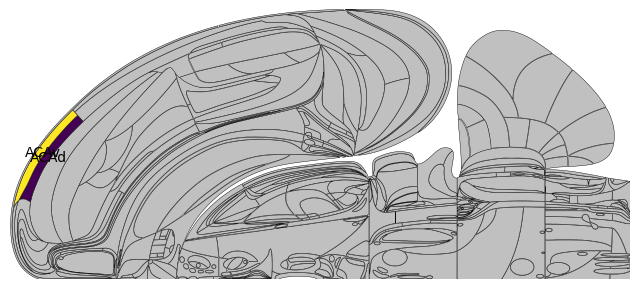

In [18]:
acronyms = ['ACAd', 'ACAv']
fig, ax = plt.subplots(figsize=(8, 6))
values = np.array([1, 2])
plot_swanson_vector(acronyms, values, annotate=True,
                    annotate_list=['ACAd', 'ACAv'],empty_color='silver',ax=ax,)
ax.set_axis_off()

In [26]:
results_df['eid']= results_df.index

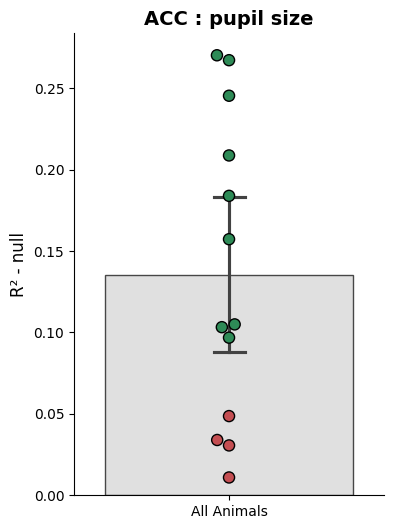

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Determine significance (adjust threshold if yours isn't 0.05)
df['is_significant'] = df['p_value'] < 0.05

# 2. Create a dummy column so Seaborn groups everything onto one bar
df['group'] = 'All Animals'

plt.figure(figsize=(4, 6))

# 3. Draw the single bar plot showing the mean and confidence interval
sns.barplot(
    data=df,
    x='group',
    y='delta',
    color='lightgray',
    edgecolor='black',
    errorbar=('ci', 95),  # Shows the 95% confidence interval of the mean
    capsize=0.1,
    alpha=0.7
)

sns.swarmplot(
    data=df,
    x='group',
    y='delta',
    hue='is_significant',
    palette={True: '#2E8B57', False: '#C44E52'},  # Green for True, Red for False
    size=8,
    linewidth=1,
    edgecolor='black',
    legend=False
)

plt.title('ACC : pupil size', fontweight='bold', fontsize=14)
plt.ylabel('R² - null', fontsize=12)
plt.xlabel('') 


sns.despine()

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [31]:


processed_sessions = []
n_splits = 5


explained_variances = {'PC1': [], 'PC2': [], 'PC3': []}

for eid, df in session_dataframes.items():
    clean_df = df.dropna(subset=['akernel_prior', 'motivation_scaled']).copy()
    
    if len(clean_df) < n_splits:
        continue
        
    clean_df['confidence_metric'] = np.abs(clean_df['akernel_prior'] - 0.5)
        
    X = np.stack(clean_df['pre_stim_spike_counts'].values)
    valid_trials = ~np.isnan(X).any(axis=1) & ~np.isinf(X).any(axis=1)
    
    if not np.all(valid_trials):
        X = X[valid_trials]
        clean_df = clean_df.iloc[valid_trials].copy()
        
    if len(clean_df) < n_splits:
        continue
        
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Extract the top 3 components
    pca = PCA(n_components=3)
    pc_scores = pca.fit_transform(X_scaled)
    
    
    evr = pca.explained_variance_ratio_
    explained_variances['PC1'].append(evr[0])
    explained_variances['PC2'].append(evr[1])
    explained_variances['PC3'].append(evr[2])
    for i in range(3):
        pc_col = pc_scores[:, i]
        clean_df[f'neural_pc{i+1}'] = (pc_col - np.mean(pc_col)) / (np.std(pc_col) + 1e-8)
    
    processed_sessions.append(clean_df)

master_df = pd.concat(processed_sessions, ignore_index=True)
master_df['eid'] = master_df['eid'].astype(str)


print("=== SHARED POPULATION VARIANCE EXPLAINED (Mean across sessions) ===")
for pc in ['PC1', 'PC2', 'PC3']:
    mean_variance = np.mean(explained_variances[pc]) * 100
    print(f"{pc}: {mean_variance:.2f}%")

model_cols = [
    'neural_pc1', 'neural_pc2', 'neural_pc3', 
    'confidence_metric', 'motivation_scaled', 'eid','feedback_binary','pupil_mean_z','is_congruent','abs_contrast','pupil_mean'
]
model_df = master_df[model_cols].copy()

=== SHARED POPULATION VARIANCE EXPLAINED (Mean across sessions) ===
PC1: 14.42%
PC2: 9.24%
PC3: 7.33%


In [32]:
model_df['is_congruent'] = ~model_df['is_congruent']

In [65]:

formula = "feedback_binary ~ neural_pc1*pupil_mean_z + is_congruent + (1 | eid)"
model = bmb.Model(formula, model_df, dropna=True)
results = model.fit(draws=2000, tune=2000, target_accept=0.95, chains=4)

Automatically removing 2/6158 rows from the dataset.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, neural_pc1, pupil_mean_z, neural_pc1:pupil_mean_z, is_congruent, 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 15 seconds.


In [83]:
model_df = model_df.dropna()

In [94]:
model_df["neural_pc1_z"] = (
    model_df["neural_pc1"] - model_df["neural_pc1"].mean()
) / model_df["neural_pc1"].std()

model_df["pupil_z"] = (
    model_df["pupil_mean_z"] - model_df["pupil_mean_z"].mean()
) / model_df["pupil_mean_z"].std()

In [95]:
model = bmb.Model(
    "feedback_binary ~ neural_pc1 + pupil_mean_z + (1 | eid)",
    model_df,
    family="bernoulli"
)

idata = model.fit()

Modeling the probability that feedback_binary==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, neural_pc1, pupil_mean_z, 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


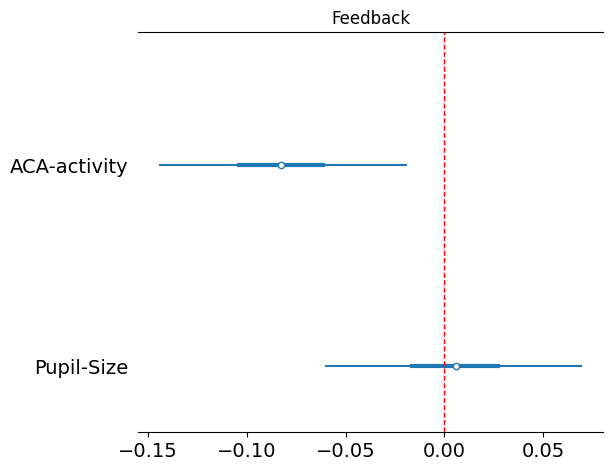

In [104]:
az.plot_forest(
    idata,
    var_names=["neural_pc1", "pupil_mean_z"],
    combined=True
)
ax = plt.gca()
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Feedback')
ax.set_yticklabels(['Pupil-Size','ACA-activity',])
plt.show()

In [34]:
model_df.rename(columns={'neural_pc1':'acc_activity', 'confidence_metric':'confidence','pupil_mean':'pupil_size','feedback_binary':'feedback'}, inplace=True)

In [ ]:
complete_df = pd.read_parquet('../data/generated/pupilometry/complete_pupil_df.pqt')
transformed_df = clean_df_zscored(complete_df)
transformed_df['confidence'] = np.abs(transformed_df['akernel_prior']-0.5)


In [ ]:
complete_df

In [46]:
eids_to_drop = model_df['eid'].unique()

In [47]:
transformed_df = transformed_df[~transformed_df['eid'].isin(eids_to_drop)]

In [49]:
bambi_formula = "pupil_mean_z ~ motivation_scaled * confidence + (1 | eid)"
model = bmb.Model(bambi_formula, transformed_df, dropna=True)
idata = model.fit(draws=2000, tune=1000, target_accept=0.95, random_seed=42)

Automatically removing 455/79818 rows from the dataset.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, motivation_scaled, confidence, motivation_scaled:confidence, 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 94 seconds.


In [55]:
summary_large = az.summary(idata, round_to=4)
prior_dict = {
    "confidence": bmb.Prior(
        "Normal", 
        mu=summary_large.loc["confidence", "mean"], 
        sigma=summary_large.loc["confidence", "sd"]
    ),
    "motivation_scaled": bmb.Prior(
        "Normal", 
        mu=summary_large.loc["motivation_scaled", "mean"], 
        sigma=summary_large.loc["motivation_scaled", "sd"]
    ),
    "motivation_scaled:confidence": bmb.Prior(
        "Normal", 
        mu=summary_large.loc["motivation_scaled:confidence", "mean"], 
        sigma=summary_large.loc["motivation_scaled:confidence", "sd"]
    )}

Text(0.5, 1.0, 'Pupil estimates')

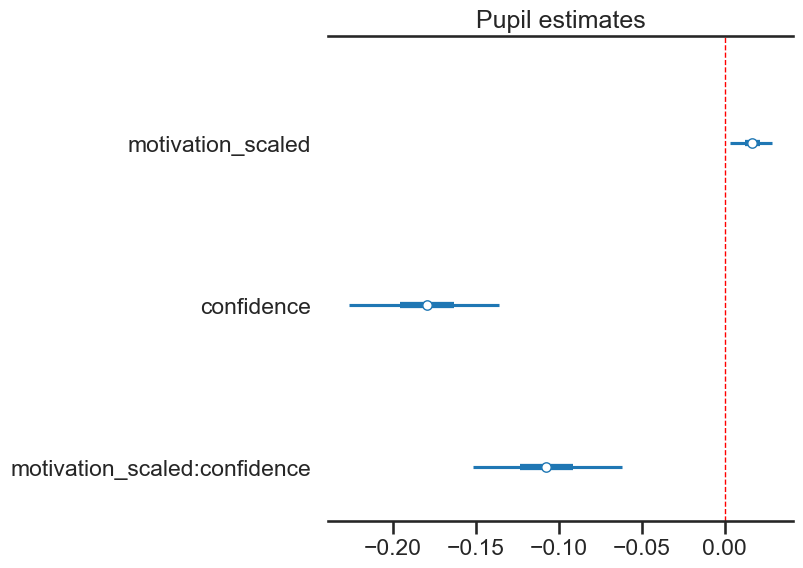

In [53]:
az.plot_forest(idata, combined=True, var_names=['motivation_scaled', 'confidence', 'motivation_scaled:confidence'])
ax.axvline(0,color='r',linestyle='--')
ax = plt.gca()
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Pupil estimates')

In [ ]:
# okay, now we use the smaller model


In [89]:
model_small = bmb.Model(
    "pupil_mean_z ~ acc_activity + motivation_scaled * confidence + (1|eid)", 
    data=model_df,
    priors=prior_dict,
    dropna=True
)
idata_small = model_small.fit(draws=2000, tune=2000, chains=4, target_accept=0.95)

Automatically removing 2/6158 rows from the dataset.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, acc_activity, motivation_scaled, confidence, motivation_scaled:confidence, 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 11 seconds.


Text(0.5, 1.0, 'Pupil estimates')

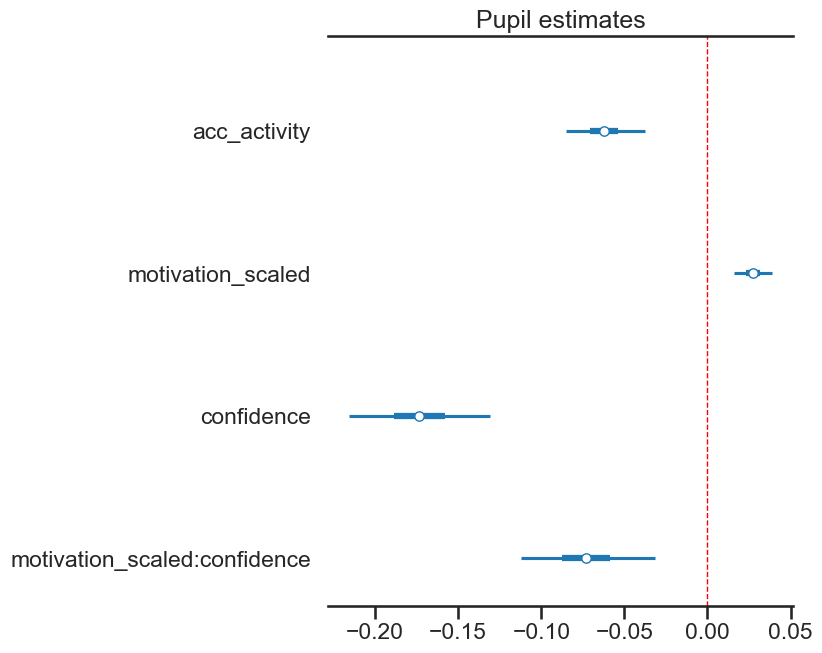

In [90]:
az.plot_forest(idata_small, combined=True, var_names=['acc_activity','motivation_scaled', 'confidence', 'motivation_scaled:confidence'])
ax.axvline(0,color='r',linestyle='--')
ax = plt.gca()
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Pupil estimates')

In [128]:
# model_df['congruence'] = model_df['is_congruent']+2